In [466]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from matplotlib import pyplot
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [468]:
alcohol = pd.read_sas('P_ALQ.XPT')
bp = pd.read_sas('P_BPQ.XPT')
diet = pd.read_sas('P_DBQ.XPT')
phys_ac = pd.read_sas('P_PAQ.XPT')
smok = pd.read_sas('P_SMQFAM.XPT')
vasc_hea = pd.read_sas('P_CDQ.XPT')

In [469]:
df1 = alcohol[['SEQN', 'ALQ130']]
df2 = bp[['SEQN', 'BPQ020', 'BPQ080']]
df3 = diet[['SEQN', 'DBQ700']]
df4 = smok[['SEQN', 'SMD460']]
df5 = phys_ac[['SEQN', 'PAD680']]
df6 = vasc_hea[['SEQN', 'CDQ001']]

In [472]:
merged_df = pd.merge(df1, df2, on='SEQN', how='inner')
merged_df = pd.merge(merged_df, df3, on='SEQN', how='inner')
merged_df = pd.merge(merged_df, df4, on='SEQN', how='inner')
merged_df = pd.merge(merged_df, df5, on='SEQN', how='inner')
merged_df = pd.merge(merged_df, df6, on='SEQN', how='inner')

merged_df = merged_df.rename(columns={"ALQ130": "avg_drink", "BPQ020": "hypertension", "BPQ080": "high_chol", 
                          "DBQ700": "diet", "SMD460": "#live_smk", "PAD680": "Sit_time_min", "CDQ001": "chest_pain"})

<Axes: >

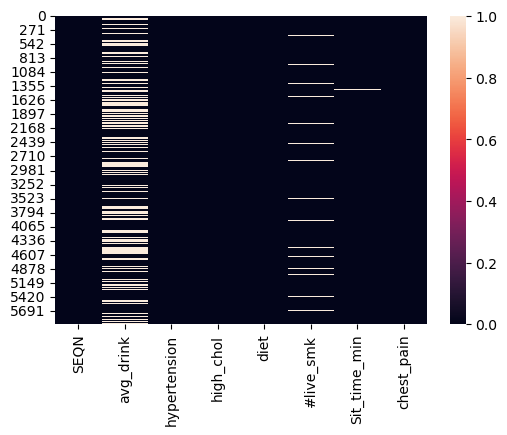

In [474]:
plt.figure(figsize=(6, 4))
sns.heatmap(merged_df.isnull())

In [475]:
df = merged_df.dropna()
df.loc[:, 'Sit_time_min'] = df['Sit_time_min'].astype(int)
df.loc[:, 'avg_drink'] = df['avg_drink'].astype(int)
df.loc[:, '#live_smk'] = df['#live_smk'].astype(int)

df = df[~df['Sit_time_min'].isin([7777, 9999])]
df = df[~df['avg_drink'].isin([777, 999])]
df = df[~df['#live_smk'].isin([777, 999])]
df = df[~df['chest_pain'].isin([9])]
df = df[~df['high_chol'].isin([7,9])]
df = df[~df['hypertension'].isin([9])]

df = df.applymap(lambda x: int(x) if isinstance(x, (int, float)) else x)
df.head()

,SEQN,avg_drink,hypertension,high_chol,diet,#live_smk,Sit_time_min,chest_pain
1,109274,2,1,1,2,0,300,2
6,109292,6,1,1,4,0,600,1
11,109305,1,2,2,2,0,240,2
12,109307,1,2,2,3,2,120,1
13,109312,1,2,2,2,0,180,2


[Text(0.5, 1.0, 'Countplot of Outcome Variable')]

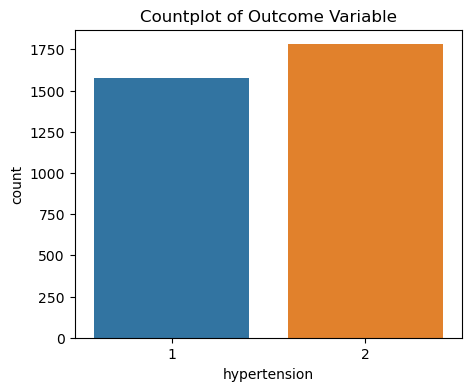

In [477]:
plt.figure(figsize=(5, 4))
sns.countplot(x = 'hypertension', data = df).set(title = 'Countplot of Outcome Variable')

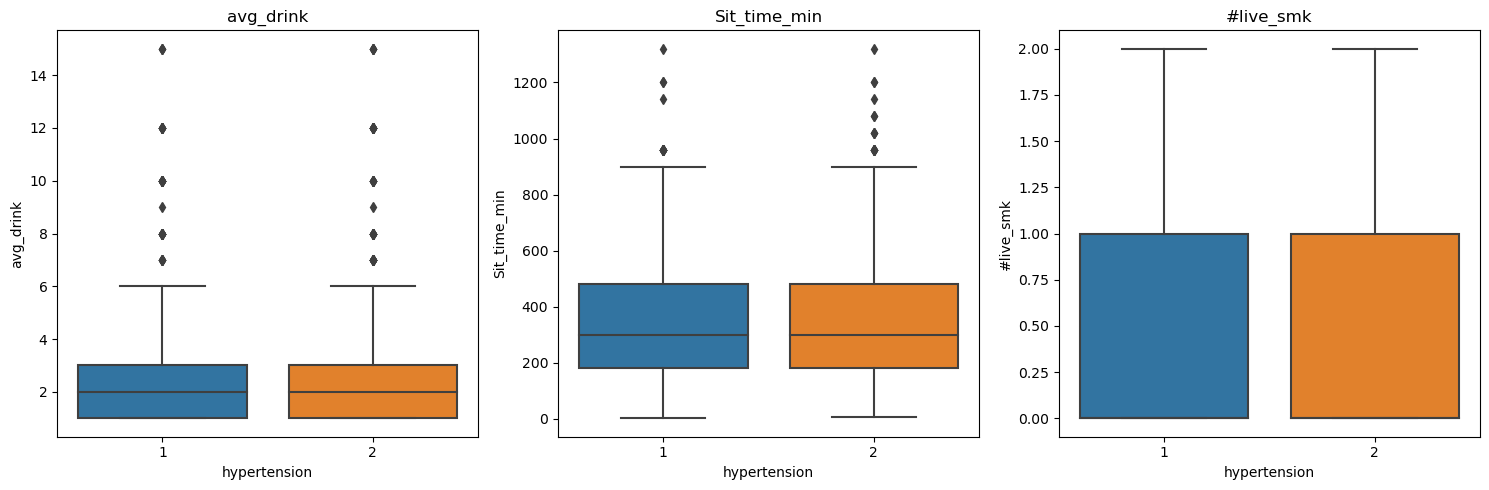

In [479]:
continuous_vars = ['avg_drink', 'Sit_time_min', '#live_smk']

# Create a histogram for each continuous variable
plt.figure(figsize=(15, 5))
for i, var in enumerate(continuous_vars):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=var, x='hypertension', data=df)
    plt.title(var)
plt.tight_layout()
plt.show()

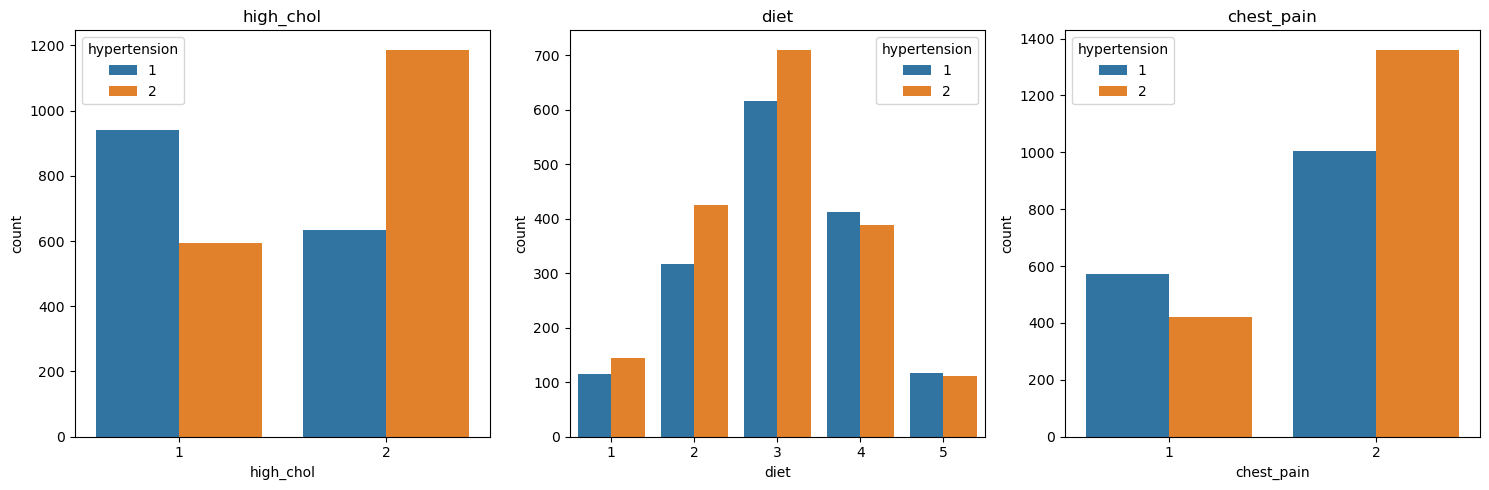

In [481]:
cate_vars = ['high_chol', 'diet', 'chest_pain']

# Create a histogram for each continuous variable
plt.figure(figsize=(15, 5))
for i, var in enumerate(cate_vars):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=var, hue ='hypertension', data=df)
    plt.title(var)
plt.tight_layout()
plt.show()

In [483]:
high_chol = pd.get_dummies(df['high_chol'])
high_chol = high_chol.drop(columns=[2], axis=1)
high_chol = high_chol.rename(columns={1: "high_chol01"})

hypertension = pd.get_dummies(df['hypertension'])
hypertension = hypertension.drop(columns=[2], axis=1)
hypertension = hypertension.rename(columns={1: "hypert01"})

diet = pd.get_dummies(df['diet'], drop_first = True)
diet = diet.rename(columns={2: "Very_good_Diet", 3: "good_Diet", 4: "Fair_Diet", 5: "Poor_Diet"})

chest_pain = pd.get_dummies(df['chest_pain'])
chest_pain = chest_pain.drop(columns=[2], axis=1)
chest_pain = chest_pain.rename(columns={1: "chest_pain01"})

df2 = pd.concat([high_chol, hypertension, diet, chest_pain], axis = 1)
df2 = df2.applymap(lambda x: 1 if x in [True, "True"] else 0 if x in [False, "False"] else x)
df2.head()

,high_chol01,hypert01,Very_good_Diet,good_Diet,Fair_Diet,Poor_Diet,chest_pain01
1,1,1,1,0,0,0,0
6,1,1,0,0,1,0,1
11,0,0,1,0,0,0,0
12,0,0,0,1,0,0,1
13,0,0,1,0,0,0,0


In [484]:
df.columns

Index(['SEQN', 'avg_drink', 'hypertension', 'high_chol', 'diet', '#live_smk',
       'Sit_time_min', 'chest_pain'],
      dtype='object')

In [485]:
df.drop(['high_chol', 'hypertension', 'diet', 'chest_pain'], axis = 1, inplace = True)
final_df = pd.concat([df, df2], axis = 1)
final_df.head()

,SEQN,avg_drink,#live_smk,Sit_time_min,high_chol01,hypert01,Very_good_Diet,good_Diet,Fair_Diet,Poor_Diet,chest_pain01
1,109274,2,0,300,1,1,1,0,0,0,0
6,109292,6,0,600,1,1,0,0,1,0,1
11,109305,1,0,240,0,0,1,0,0,0,0
12,109307,1,2,120,0,0,0,1,0,0,1
13,109312,1,0,180,0,0,1,0,0,0,0


In [486]:
from sklearn.preprocessing import StandardScaler

X = final_df.drop(['hypert01', 'SEQN'], axis=1)
y = final_df['hypert01']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [492]:
logmod = LogisticRegression(penalty='l1', solver='liblinear')

alphas = np.logspace(-4, 4, 9)  # Example range, you can adjust as needed

# Perform grid search with cross-validation to find optimal alpha
param_grid = {'C': 1/alphas}  # C is the inverse of regularization strength
grid_search = GridSearchCV(logmod, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Get the optimal alpha and best score
optimal_alpha = grid_search.best_params_['C']
best_score = grid_search.best_score_
print("Optimal Alpha:", optimal_alpha)
print("Best Score:", best_score)

# Fit the model with the optimal alpha on the entire training data
final_model = LogisticRegression(penalty='l1', solver='liblinear', C=optimal_alpha)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# Evaluate the model on the test data
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Optimal Alpha: 0.1
Best Score: 0.6345687973506328
Accuracy: 0.64


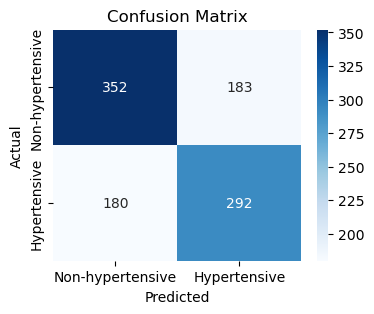

In [494]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-hypertensive', 'Hypertensive'],
            yticklabels=['Non-hypertensive', 'Hypertensive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

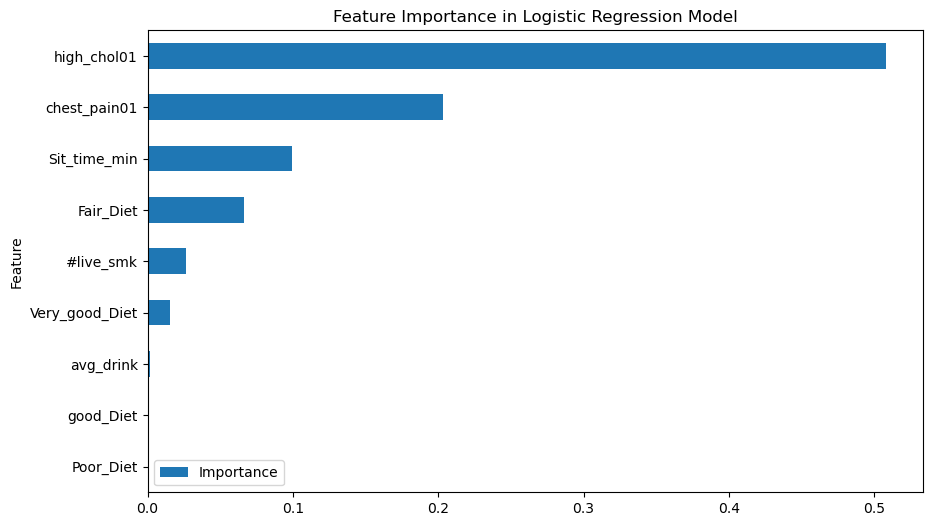

In [504]:
coefficients = final_model.coef_[0]

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
ax = feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))
ax.set_title('Feature Importance in Logistic Regression Model')
plt.show()